### 1. Fundamental Parameters

In [1]:
from model import alpha, self_energy
from smatrix import create_self_energy_interpolator_numba
import numpy as np
from eigenstate_solving import BZ_proj
from model import square_lattice
from W_state import q_bounds


sigma_data = np.load("../../data/sigma_grid0f1a.npz")
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
collective_lamb_shift = self_energy(
    0, 0, square_lattice.a, square_lattice.d, square_lattice.omega_e, alpha
).real
sigma_func_period = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
# r_para = np.array([-74, 30])
# p_para = np.array([60, 50])
r_para = np.array([-74, 30])
p_para = np.array([0, 0])

E = 2 * (square_lattice.omega_e + collective_lamb_shift)
E1 = (E-2) / 2

Q_para = np.array([0, 0])
sigma_func_period = sigma_func_period_numba
Zc = 1


q_min, q_max = q_bounds(E, r_para, Q_para, square_lattice)

"""
k_para = np.array([50, 50])
E = square_lattice.omega_e

kz = np.sqrt(E**2 - np.hypot(k_para[0], k_para[1]) ** 2)
k = np.concatenate((k_para, np.array([kz])))

print(square_lattice.ge(k))
print(
    (
        -2
        * square_lattice.a**2
        * np.imag(sigma_func_period(k_para[0], k_para[1]))
        * (kz / E)
    )
    ** (1 / 2)
)
"""


'\nk_para = np.array([50, 50])\nE = square_lattice.omega_e\n\nkz = np.sqrt(E**2 - np.hypot(k_para[0], k_para[1]) ** 2)\nk = np.concatenate((k_para, np.array([kz])))\n\nprint(square_lattice.ge(k))\nprint(\n    (\n        -2\n        * square_lattice.a**2\n        * np.imag(sigma_func_period(k_para[0], k_para[1]))\n        * (kz / E)\n    )\n    ** (1 / 2)\n)\n'

Near the zeros of the denominator, its Taylor expansion is $\partial_q \Big[ (\tilde{E}_1 -\omega_e \Sigma(\mathbf{r}_\parallel))(E-\tilde{E}_1-\Sigma r(Q_\parallel-r_\parallel))\left(t(r_\parallel,\tilde{E}_1)t(r(Q_\parallel-r_\parallel),E-\tilde{E}_1)\right)|_{q=\mathrm{root}}\times (E-\tilde{E}_1)\Big]+i\eta$ where $\tilde{E}_1=\sqrt{|k_\parallel|^2+(K_z/2+q)^2}$. For the simplicity of notation, we define $D_0(\mathbf{r}_\parallel;E_1,\mathbf{p}_\parallel,E,\mathbf{Q}_\parallel):=\partial_q \left(t(r_\parallel,\tilde{E}_1)t(r(Q_\parallel-r_\parallel),E-\tilde{E}_1)\right)|_{q=\mathrm{root}}$ We can factor out the derivative term, obtaining $D_0(\mathbf{r}_\parallel;E_1,\mathbf{p}_\parallel,E,\mathbf{Q}_\parallel)\times \Big[q-q_{\mathrm{root}}+i\eta/\left(D_0(\mathbf{r}_\parallel;E_1,\mathbf{p}_\parallel,E,\mathbf{Q}_\parallel)\right) \Big]$. We see that the second term is a Lorentzian function with a peak width $2\eta/\operatorname{Re}\Big[D_0(\mathbf{r}_\parallel;E_1,\mathbf{p}_\parallel,E,\mathbf{Q}_\parallel)\Big]$. To guarentee that this peak the resolved by `n_Rs` points in q grid. $\eta$ is estimated as $\eta=1/2\,R_s\,\Delta q\,D_0(\mathbf{r}_\parallel;E_1,\mathbf{p}_\parallel,E,\mathbf{Q}_\parallel)$

In [2]:
from scipy.differentiate import derivative
from W_state import _denom_BM
from smatrix import t_reg


def eta_estimator(r_para, p_para, E1, E, Q_para, lattice, sigma_func_period, dq, n_Rs):
    """Estimate the imaginary regulator needed to resolve q-axis poles.

    The denominator can develop real poles as a function of the relative
    z-momentum ``q``. This routine locates those candidate poles,
    discards poles with negligible imaginary parts or poles outside the
    q-grid bounds, and returns ``0.0`` when no regulator is needed.

    For real poles inside the grid, ``eta`` is chosen from the largest local
    slope of ``Re(denominator)`` at the pole locations. The estimate broadens
    the Lorentzian peak so its width is resolved by approximately ``n_Rs``
    grid spacings of size ``dq``.
    """


    def pole_loc(r_para, p_para, E1, E, Q_para, lattice, sigma_func_period):
        """Find pole locations along the q axis using the quadratic formula.

        Returns
        -------
        list[list[float]]
            A list of pole locations. Each entry is ``[q, Kz]``, where ``q`` is the
            real pole coordinate along the q axis and ``Kz`` is the corresponding
            total z-direction wavevector. Small numerical imaginary parts are
            discarded before returning.
        """
        s_para = BZ_proj(Q_para - r_para, lattice)
        # eigenvalue of this W state
        tt = t_reg(p_para, E1, lattice, sigma_func_period) * t_reg(
            BZ_proj(Q_para - p_para, lattice), E - E1, lattice, sigma_func_period
        )
        # self-energy terms
        Sigma1 = sigma_func_period(r_para[0], r_para[1])
        Sigma2 = sigma_func_period(s_para[0], s_para[1])

        # the follows are the coefficient terms in the quadratic equation
        # coefficient for q**2
        A = tt - 1
        # coefficient for q
        B = (
            E * (1 - tt)
            + (
                sigma_func_period(s_para[0], s_para[1])
                - sigma_func_period(r_para[0], r_para[1])
            )
            * tt
            + np.conj(sigma_func_period(r_para[0], r_para[1]))
            - np.conj(sigma_func_period(s_para[0], s_para[1]))
        )
        # constant term
        C = (
            E * Sigma1 * tt
            - Sigma1 * Sigma2 * tt
            - E * lattice.omega_e
            + E * tt * lattice.omega_e
            - Sigma1 * tt * lattice.omega_e
            - Sigma2 * tt * lattice.omega_e
            + lattice.omega_e**2
            - tt * lattice.omega_e**2
            - E * np.conjugate(Sigma1)
            + lattice.omega_e * np.conjugate(Sigma1)
            + lattice.omega_e * np.conjugate(Sigma2)
            + np.conjugate(Sigma1) * np.conjugate(Sigma2)
        )

        # coefficient for q**0
        determinant = B**2 - 4 * A * C
        determinant = complex(determinant)

        # quadratic formula
        root = [
            (-B + np.sqrt(determinant)) / (2 * A),
            (-B - np.sqrt(determinant)) / (2 * A),
        ]

        # The imaginary part of the root for E1tilde never vanishes exactly due to numerical errors, but it should be discarded when it is small enough.
        if np.any(np.abs(np.imag(root)) > 1e-6):
            return None

        val_list = []
        # convert the root in E1tilde to the corresponding q and Kz values
        for E1tilde in root:
            rz = np.sqrt(E1tilde**2 - np.hypot(r_para[0], r_para[1]) ** 2)
            sz = np.sqrt((E - E1tilde) ** 2 - np.hypot(s_para[0], s_para[1]) ** 2)

            q = (rz - sz) / 2
            Kz = rz + sz
            if np.abs(np.imag(q)) > 1e-5:
                return None
            if np.abs(np.imag(Kz)) > 1e-5:
                return None

            # discard the small imainary part of q and Kz
            q = np.real(q)
            if q < q_min or q > q_max:
                continue
            Kz = np.real(Kz)
            val_list.append([q, Kz])

        return val_list

    q_root_list = pole_loc(
        r_para, p_para, E1, E, Q_para, lattice, sigma_func_period
    )

    if (
        q_root_list is None
    ):  # if the pole is not on the real axis, we do not need the regulator eta.
        print("Pole is not on the real axis, no regulator needed. eta=0.0")
        return 0.0
    elif not q_root_list:  # if the pole is on the real axis but outside of the q grid, we also do not need the regulator eta.
        print(f"Pole is not in the interval of [{q_min}, {q_max}], no regulator needed. eta=0.0")
        return 0.0
    else:
        q_roots = [root[0] for root in q_root_list]

        def denom_complex_scalar(q):
            return _denom_BM(
                r_para,
                float(q),
                p_para,
                E1,
                E,
                Q_para,
                lattice,
                sigma_func_period,
            )

        def denom_re(q):
            return np.vectorize(
                lambda x: np.real(denom_complex_scalar(x)), otypes=[float]
            )(q)

        d_re_values = [np.abs(derivative(denom_re, q_root).df) for q_root in q_roots]
        d_re_max = max(d_re_values)

        estimated_eta = 0.5 * n_Rs * d_re_max * dq
    #    print(f"Estimated eta for resolving the pole: {estimated_eta}")

        return estimated_eta

### 2. Discrete FFT Part

For the discrete FFT grid used below, $q_j=q_{\min}+j\Delta q$ with `endpoint=False`, so $\Delta q\simeq(q_{\max}-q_{\min})/n$ (up to the small endpoint offset). The conjugate coordinate grid is $z_k=2\pi\,\mathrm{fftfreq}(n,d=\Delta q)$, so the non-aliased range is $|z|\le L$ with $L=\pi/\Delta q$, and the spacing is $\Delta z=2L/n=2\pi/(n\Delta q)$.

Pole is not on the real axis, no regulator needed. eta=0.0
Estimated eta for resolving the pole: 0.0


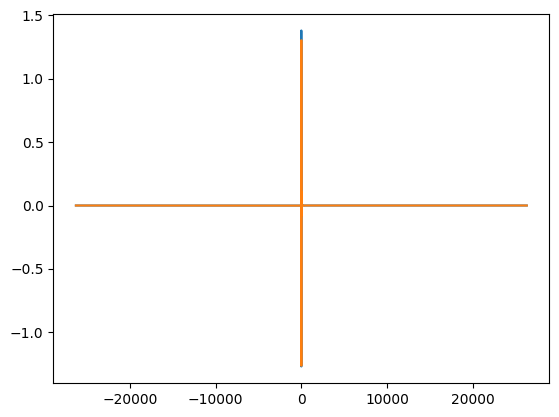

In [ ]:
from scipy.fft import ifft
from W_state import W_k_sp_grid
import matplotlib.pyplot as plt

n_points = int(2e6)

q_min, q_max = q_bounds(E, r_para, Q_para, square_lattice)
q_grid = np.linspace(q_min + 1e-10, q_max - 1e-10, n_points, endpoint=False)
dq = q_grid[1] - q_grid[0]
eta_estimated = eta_estimator(
    r_para, p_para, E1, E, Q_para, square_lattice, sigma_func_period, dq, 10
)
print(f"Estimated eta for resolving the pole: {eta_estimated}")
eta = 1e-3
q_grid, value_grid = W_k_sp_grid(
    r_para,
    p_para,
    E1,
    E,
    Q_para,
    Zc,
    square_lattice,
    sigma_func_period,
    n_points,
    eta=eta,
)
dq = q_grid[1] - q_grid[0]
L = np.pi / dq  # Nyquist limit

z_grid = 2 * np.pi * np.fft.fftfreq(n_points, d=dq)

# value_grid_ifft = (q_max-q_min)*ifft(value_grid)
value_grid_ifft = n_points * dq * ifft(value_grid)
value_grid_ifft *= np.exp(1j * q_grid[0] * z_grid)

# Only compare where the q grid resolves exp(i q z) with several samples per period.
nyquist_z = np.pi / dq
min_samples_per_period = 8
resolved_z = 2 * np.pi / (min_samples_per_period * dq)
keep = np.abs(z_grid) <= resolved_z


plot_idx = np.argsort(z_grid[keep])
plt.plot(z_grid[keep][plot_idx], np.real(value_grid_ifft[keep][plot_idx]))
plt.plot(z_grid[keep][plot_idx], np.imag(value_grid_ifft[keep][plot_idx]))
plt.show()

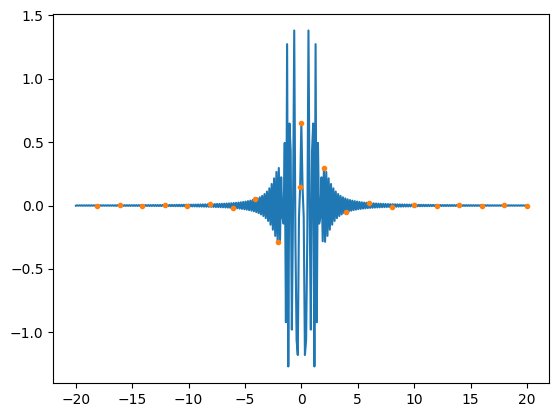

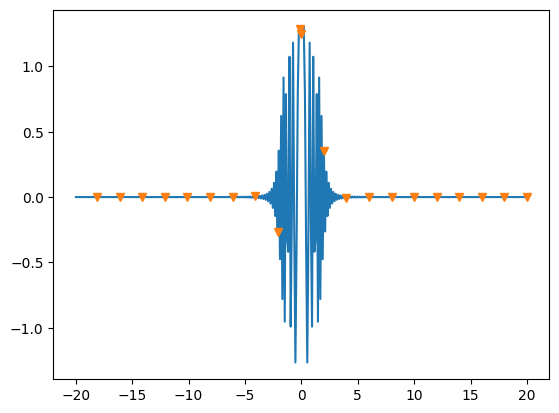

In [4]:
from W_state import quad_FT 

plot_mask = np.abs(z_grid) <= 20
plot_z_grid = z_grid[plot_mask]
plot_value_grid_ifft = value_grid_ifft[plot_mask]

n_intg_sample_point = 20
sample_step = max(1, len(plot_z_grid) // n_intg_sample_point)
z_sample = plot_z_grid[::sample_step]

quad_result = []
quad_err = []
for z_val in z_sample:
    val, err = quad_FT(
        r_para,
        p_para,
        Zc,
        z_val,
        E1,
        E,
        Q_para,
        square_lattice,
        sigma_func_period,
        eta=eta,
    )
    quad_result.append(val)
    quad_err.append(err)
quad_result = np.asarray(quad_result)
quad_err = np.asarray(quad_err)


sorted_idx = np.argsort(plot_z_grid)
plt.plot(plot_z_grid[sorted_idx], np.real(plot_value_grid_ifft[sorted_idx]))
plt.plot(z_sample, np.real(quad_result), ".")
plt.show()

plt.plot(plot_z_grid[sorted_idx], np.imag(plot_value_grid_ifft[sorted_idx]))
plt.plot(z_sample, np.imag(quad_result), "v")
plt.show()

In [5]:
mask_tmp = (q_grid <= 1.5) & (q_grid >= 0.8)
#plt.plot(q_grid[mask_tmp], np.real(value_grid)[mask_tmp])
#plt.plot(q_grid[mask_tmp], np.imag(value_grid)[mask_tmp])


In [6]:
from collections import deque
from joblib import Parallel, delayed


r_para_path = deque()
n_r_grid_points = 5 # number of grid points along each direction in the r_para path inside the light cone

E = 2 * (square_lattice.omega_e + collective_lamb_shift)
r_grid_points =  np.linspace(0,E/2,n_r_grid_points,False)
r_path = deque()

# go through the grid in reverse order but skip the first point (0,0) to avoid duplication
for x in r_grid_points[:1:-1]:
    r_path.append(np.array([x, 0.0]))
"""
for x in r_grid_points:
    r_path.append([x, x])
"""

n_jobs = 6  # use all available CPU cores; set to a positive integer to limit workers

def _compute_q_distribution(r_para):
    q_grid, q_distribution =  W_k_sp_grid(
        r_para,
        p_para,
        E1,
        E,
        Q_para,
        Zc,
        square_lattice,
        sigma_func_period,
        n_points,
        eta=eta,
    )
    return q_grid, q_distribution

q_distribution_results = Parallel(n_jobs=n_jobs, verbose=3)(
    delayed(_compute_q_distribution)(r_para) for r_para in r_path
)
q_grid_list, q_distribution_list = map(list, zip(*q_distribution_results))





[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   3 | elapsed:  5.2min finished


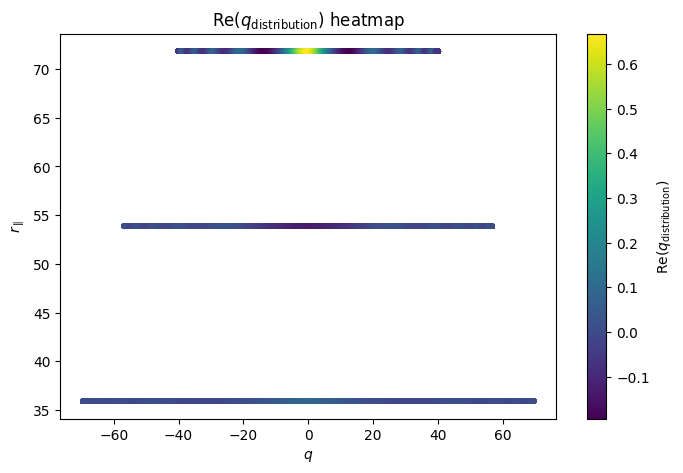

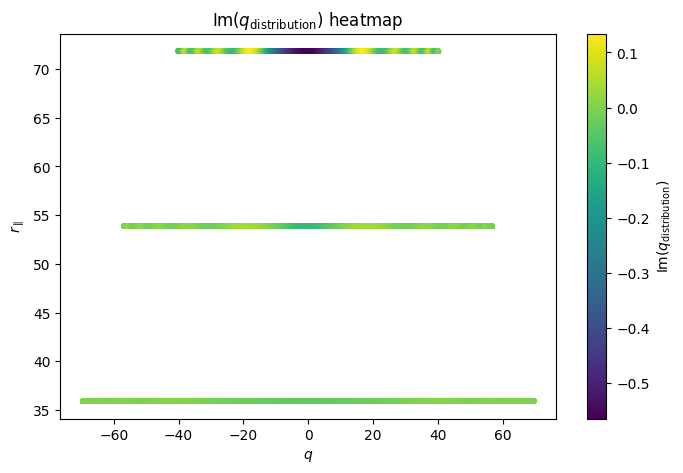

In [7]:
r_heatmap_points = r_grid_points[:1:-1]
q_re = np.real(np.asarray(q_distribution_list))
q_im = np.imag(np.asarray(q_distribution_list))

if q_re.shape[0] != len(r_heatmap_points) or q_im.shape[0] != len(r_heatmap_points):
    raise ValueError("The number of q_distribution rows must match r_heatmap_points.")

def _plot_q_distribution_heatmap(values, colorbar_label, title):
    if "q_grid_list" in globals() and all(np.allclose(q_grid_list[0], q) for q in q_grid_list[1:]):
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(q_grid_list[0], r_heatmap_points, values, shading="auto")
    elif "q_grid_list" in globals():
        q_heatmap_grid = np.asarray(q_grid_list)
        r_heatmap_grid = np.repeat(r_heatmap_points[:, None], q_heatmap_grid.shape[1], axis=1)
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.scatter(q_heatmap_grid.ravel(), r_heatmap_grid.ravel(), c=values.ravel(), s=8)
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(q_grid, r_heatmap_points, values, shading="auto")

    fig.colorbar(mesh, ax=ax, label=colorbar_label)
    ax.set_xlabel(r"$q$")
    ax.set_ylabel(r"$r_\parallel$")
    ax.set_title(title)
    plt.show()

_plot_q_distribution_heatmap(
    q_re,
    r"$\mathrm{Re}(q_{\mathrm{distribution}})$",
    r"$\mathrm{Re}(q_{\mathrm{distribution}})$ heatmap",
)
_plot_q_distribution_heatmap(
    q_im,
    r"$\mathrm{Im}(q_{\mathrm{distribution}})$",
    r"$\mathrm{Im}(q_{\mathrm{distribution}})$ heatmap",
)
